# 17 — Embeddings: style fingerprint

Style is the third leg of the music-theoretic decomposition of Collatz orbits
(after keys and progressions). Two orbits with similar **style fingerprints**
should "feel the same" dynamically — same rhythm of step sizes, same flavour
of mod-3 transitions — even if they live in different keys (different
classes) or play different tunes.

We operationalise style as the empirical distribution over local patterns:

- `alpha_histogram(n)`: PMF of alpha values along the Syracuse orbit.
- `mod3_transition_histogram(n)`: PMF of (mod3, mod3) transitions among the
  in-{1,2} odd values of the orbit.
- `style_fingerprint(n)`: the concatenation, length 13 by default.

Distance between fingerprints is a normalized chi-squared distance in [0, 1].

This notebook does five things:
1. Sanity / fixtures on small `n`.
2. Style clustering by dropping set.
3. Key-invariance test.
4. Same-style analogy quads.
5. Tempo-invariance test.

In [1]:
import sys
sys.path.insert(0, "..")

import random
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

from collatz.core import alpha_sequence
from collatz.dropping import dropping_set
from collatz.utils import members_of_class
from collatz.embeddings.concept import Concept
from collatz.embeddings.style import (
    alpha_histogram,
    mod3_transition_histogram,
    style_fingerprint,
    style_distance,
    concept_style_distance,
    style_analogy,
    nearest_style,
)
from collatz.embeddings.trajectory import (
    syracuse_orbit,
    concept_orbit_distance,
    trajectory_analogy,
)
from collatz.embeddings.iteration import _syr_step

random.seed(0)
np.random.seed(0)

## 1. Sanity / fixtures

Inspect the alpha histogram and mod3-transition histogram for some small `n`
and check that the distributions look reasonable.

In [2]:
fixtures = [3, 5, 7, 11, 27]

for n in fixtures:
    alpha_seq = alpha_sequence(n)
    h_alpha = alpha_histogram(n)
    h_mod3 = mod3_transition_histogram(n)
    print(f"n={n:>3}  alpha_seq (len={len(alpha_seq)}): {alpha_seq}")
    print(f"        alpha_hist:  {[round(x, 3) for x in h_alpha]}")
    print(f"        mod3_trans:  {[round(x, 3) for x in h_mod3]}")
    print()

n=  3  alpha_seq (len=2): [1, 4]
        alpha_hist:  [0.0, 0.5, 0.0, 0.0, 0.5, 0.0, 0.0, 0.0, 0.0]
        mod3_trans:  [0.0, 0.0, 0.0, 0.0]

n=  5  alpha_seq (len=1): [4]
        alpha_hist:  [0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0]
        mod3_trans:  [0.0, 0.0, 0.0, 0.0]

n=  7  alpha_seq (len=5): [1, 1, 2, 3, 4]
        alpha_hist:  [0.0, 0.4, 0.2, 0.2, 0.2, 0.0, 0.0, 0.0, 0.0]
        mod3_trans:  [0.0, 0.5, 0.25, 0.25]

n= 11  alpha_seq (len=4): [1, 2, 3, 4]
        alpha_hist:  [0.0, 0.25, 0.25, 0.25, 0.25, 0.0, 0.0, 0.0, 0.0]
        mod3_trans:  [0.0, 0.333, 0.333, 0.333]

n= 27  alpha_seq (len=41): [1, 2, 1, 1, 1, 1, 2, 2, 1, 2, 1, 1, 2, 1, 1, 1, 2, 3, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1, 3, 1, 1, 1, 4, 2, 2, 4, 3, 1, 1, 5, 4]
        alpha_hist:  [0.0, 0.585, 0.244, 0.073, 0.073, 0.024, 0.0, 0.0, 0.0]
        mod3_trans:  [0.103, 0.205, 0.205, 0.487]



**Read:**
- For `n=3` and `n=5` the orbit is short (alpha_seq length 1 or 2), so
  mod3_transition is the all-zero sentinel — there aren't enough in-{1,2}
  residues to form a transition.
- For `n=27` (orbit length 41) we see a wide alpha distribution and a clearly
  non-uniform mod3 transition matrix (the (2,2) cell dominates ≈ 49%, the
  (1,1) cell is rare ≈ 10%).

## 2. Style clusters by dropping set?

Sample 30 integers from each of `Set_3`, `Set_6`, `Set_8`. Compute pairwise
`style_distance` and plot as a heatmap. Same-set blocks should look darker
(smaller distance) than off-diagonal blocks if style tracks dropping set.

In [3]:
def sample_set(k, n_samples, limit=20000, rng_seed=0):
    rng = random.Random(rng_seed + k)
    members = members_of_class(dropping_set, k, limit)
    if len(members) >= n_samples:
        return rng.sample(members, n_samples)
    return members[:n_samples]

samples = {
    3: sample_set(3, 30, rng_seed=1),
    6: sample_set(6, 30, rng_seed=2),
    8: sample_set(8, 30, rng_seed=3),
}
for k, ns in samples.items():
    print(f"Set_{k}: {len(ns)} samples, e.g. {ns[:6]}")

Set_3: 30 samples, e.g. [7737, 9941, 3385, 12981, 15693, 5081]
Set_6: 30 samples, e.g. [7427, 12131, 12291, 4131, 6323, 1427]
Set_8: 30 samples, e.g. [14827, 18347, 15255, 14807, 16651, 19243]


In [4]:
# Build a flat ordered list and class label vector.
groups = [3, 6, 8]
flat = []
labels = []
for k in groups:
    for n in samples[k]:
        flat.append(n)
        labels.append(k)
N = len(flat)

# Pairwise style distance matrix.
D = np.zeros((N, N), dtype=np.float64)
for i in range(N):
    for j in range(i + 1, N):
        d = style_distance(flat[i], flat[j])
        D[i, j] = d
        D[j, i] = d

# Mean distance within each (group, group) block.
print("Mean style_distance by (group_a, group_b):")
print(f"{'':>8s}", *[f"Set_{k:<3d}" for k in groups], sep="  ")
for ka in groups:
    row = [f"Set_{ka}"]
    for kb in groups:
        idx_a = [i for i, lab in enumerate(labels) if lab == ka]
        idx_b = [i for i, lab in enumerate(labels) if lab == kb]
        vals = []
        for i in idx_a:
            for j in idx_b:
                if i != j:
                    vals.append(D[i, j])
        row.append(f"{np.mean(vals):.4f}")
    print(f"{row[0]:>8s}", *[f"{r:>7s}" for r in row[1:]], sep="  ")

Mean style_distance by (group_a, group_b):
          Set_3    Set_6    Set_8  
   Set_3   0.1241   0.1400   0.1075
   Set_6   0.1400   0.1582   0.1233
   Set_8   0.1075   0.1233   0.0866


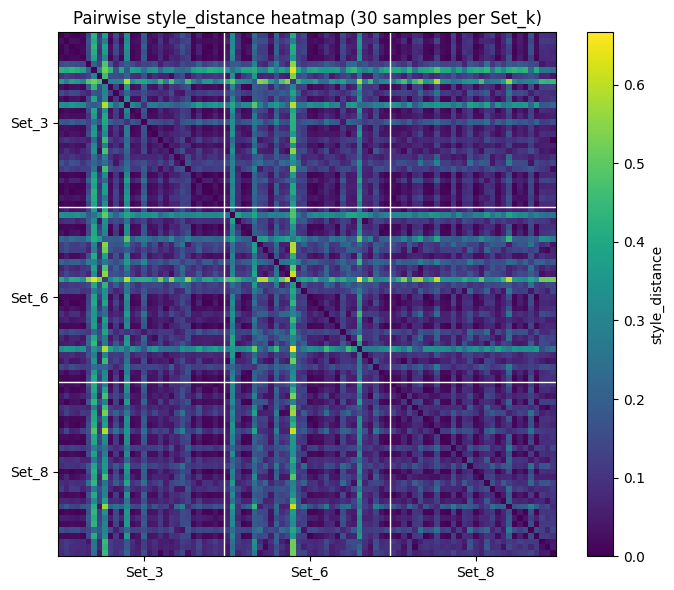

In [5]:
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(D, cmap="viridis", aspect="auto")
plt.colorbar(im, ax=ax, label="style_distance")
# Group separators.
ticks = []
tick_labels = []
boundaries = []
acc = 0
for k in groups:
    cnt = sum(1 for lab in labels if lab == k)
    ticks.append(acc + cnt // 2)
    tick_labels.append(f"Set_{k}")
    acc += cnt
    boundaries.append(acc)
for b in boundaries[:-1]:
    ax.axhline(b - 0.5, color="white", linewidth=1)
    ax.axvline(b - 0.5, color="white", linewidth=1)
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(tick_labels)
ax.set_yticklabels(tick_labels)
ax.set_title("Pairwise style_distance heatmap (30 samples per Set_k)")
plt.tight_layout()
plt.show()

**Read:** if same-set blocks are visibly darker than the off-diagonal blocks,
style fingerprints encode dropping-set membership. The block means table is
the more honest readout: compare the within-set diagonal entries against the
cross-set entries.

## 3. Style is key-invariant?

Pick two integers in different cosets but in the same Set_k. Their
fingerprints should be similar (same Set_k -> shared dynamical character).
Compare to integers in different Set_k.

In [6]:
# Two from Set_3 (different cosets), two from Set_6, two from Set_8.
def first_n_from_class(k, n, limit=20000):
    return members_of_class(dropping_set, k, limit)[:n]

trio_3 = first_n_from_class(3, 4)
trio_6 = first_n_from_class(6, 4)
trio_8 = first_n_from_class(8, 4)

print("Set_3:", trio_3)
print("Set_6:", trio_6)
print("Set_8:", trio_8)

print()
print("Within-class style_distance:")
for k, ns in [("Set_3", trio_3), ("Set_6", trio_6), ("Set_8", trio_8)]:
    pairs = []
    for i, a in enumerate(ns):
        for b in ns[i + 1:]:
            pairs.append(style_distance(a, b))
    print(f"  {k}: mean={np.mean(pairs):.4f}, max={max(pairs):.4f}")

print()
print("Cross-class style_distance (one from each):")
for ka, na in [("Set_3", trio_3[0]), ("Set_6", trio_6[0]), ("Set_8", trio_8[0])]:
    for kb, nb in [("Set_3", trio_3[1]), ("Set_6", trio_6[1]), ("Set_8", trio_8[1])]:
        if ka != kb:
            print(f"  {ka}({na}) vs {kb}({nb}): {style_distance(na, nb):.4f}")

Set_3: [5, 9, 13, 17]
Set_6: [3, 19, 35, 51]
Set_8: [11, 23, 43, 55]

Within-class style_distance:
  Set_3: mean=0.4003, max=0.6071
  Set_6: mean=0.3452, max=0.4571
  Set_8: mean=0.2877, max=0.5712

Cross-class style_distance (one from each):
  Set_3(5) vs Set_6(19): 0.6071
  Set_3(5) vs Set_8(23): 0.5500
  Set_6(3) vs Set_3(9): 0.4250
  Set_6(3) vs Set_8(23): 0.3333
  Set_8(11) vs Set_3(9): 0.0286
  Set_8(11) vs Set_6(19): 0.0256


**Read:** within-class means should generally be smaller than cross-class
distances. If they are, "style" is invariant to the choice of coset within
a class — the music-theoretic claim that style is key-invariant.

## 4. Same-style analogy quads (n=30, ~100 distractors)

Build quads where (a, b) are two integers from the same Set_k (so similar
style), (c, d) similarly. Distractors: random odd integers across many Set_k.
Run `style_analogy` and report rank of expected `d`. Compare to
`trajectory_analogy` (orbit-Jaccard).

In [7]:
def build_same_set_quads(n_quads=30, sets=(3, 6, 8, 11), limit=20000, rng_seed=0):
    """Each quad: (a, b) from one Set_k; (c, d) from another Set_k."""
    rng = random.Random(rng_seed)
    quads = []
    pools = {k: members_of_class(dropping_set, k, limit) for k in sets}
    for _ in range(n_quads):
        ks = rng.sample(list(sets), 2)
        ka, kc = ks[0], ks[1]
        a, b = rng.sample(pools[ka], 2)
        c, d = rng.sample(pools[kc], 2)
        quads.append(((a, b, c, d), (ka, kc)))
    return quads


def random_distractors(n, sets=(3, 6, 8, 11, 13, 16), limit=20000, rng_seed=42):
    rng = random.Random(rng_seed)
    pool = []
    for k in sets:
        pool.extend(members_of_class(dropping_set, k, limit))
    rng.shuffle(pool)
    return pool[:n]


quads = build_same_set_quads(n_quads=30, rng_seed=7)
distractors = random_distractors(100, rng_seed=42)

# Distractor pool excludes the (a, b, c, d) of each quad.
def evaluate(quads, distractors, *, embed):
    """For each quad, build candidate list = [d] + distractors, run analogy
    function `embed`, return rank of d (1-indexed)."""
    ranks = []
    for (a_n, b_n, c_n, d_n), (ka, kc) in quads:
        # Convert to single-component Concepts.
        A = Concept(f"a", (a_n,))
        B = Concept(f"b", (b_n,))
        C = Concept(f"c", (c_n,))
        D = Concept(f"d", (d_n,))
        # Distractors as concepts (excluding any that match d_n).
        D_pool = [Concept(f"x{n}", (n,)) for n in distractors if n != d_n]
        candidates = [D] + D_pool
        scored = embed(A, B, C, candidates)
        # Find rank of D.
        for r, (cand, _score) in enumerate(scored, start=1):
            if cand.vec == D.vec and cand.name == D.name:
                ranks.append(r)
                break
    return np.array(ranks)


ranks_style = evaluate(quads, distractors, embed=style_analogy)
ranks_traj = evaluate(quads, distractors, embed=trajectory_analogy)

print(f"# candidates per quad: {len(distractors)}")
print(f"Chance baseline mean rank: {(len(distractors)) / 2:.1f}")
print()
print(f"style_analogy:      mean rank = {ranks_style.mean():.2f}, median = {np.median(ranks_style):.0f}")
print(f"                    top-1 hits  = {(ranks_style == 1).sum()}/{len(ranks_style)}")
print(f"                    top-5 hits  = {(ranks_style <= 5).sum()}/{len(ranks_style)}")
print()
print(f"trajectory_analogy: mean rank = {ranks_traj.mean():.2f}, median = {np.median(ranks_traj):.0f}")
print(f"                    top-1 hits  = {(ranks_traj == 1).sum()}/{len(ranks_traj)}")
print(f"                    top-5 hits  = {(ranks_traj <= 5).sum()}/{len(ranks_traj)}")

# candidates per quad: 100
Chance baseline mean rank: 50.0

style_analogy:      mean rank = 54.47, median = 57
                    top-1 hits  = 0/30
                    top-5 hits  = 0/30

trajectory_analogy: mean rank = 49.50, median = 56
                    top-1 hits  = 0/30
                    top-5 hits  = 1/30


**Read:** the lower the mean rank, the better the embedding identifies the
"correct" same-style answer. Chance = ~50 (with 100 distractors). Both style
and trajectory are similarity-based: their job here is to find a `d` whose
relationship to `c` mirrors the relationship between `a` and `b`. Style
should do well on quads where (a, b, c, d) are all from the same Set_k pair,
because the relationship is "stylistically similar".

## 5. Tempo invariance test

We expect: orbits with different LENGTHS but similar fingerprints get small
style_distance. A long orbit and a very short orbit should be far apart
(short orbits don't have enough samples to populate the distribution
faithfully). Two long orbits with similar fingerprints should be close.

In [8]:
# Long orbits and a short orbit.
short = 5      # alpha_sequence has length 1
medium = 7     # length 5
long_a = 27    # length 41
long_b = 41    # length ~38, similar style as 27

print(f"alpha_sequence lengths: 5 -> {len(alpha_sequence(5))}, 7 -> {len(alpha_sequence(7))}, 27 -> {len(alpha_sequence(27))}, 41 -> {len(alpha_sequence(41))}")
print(f"orbit lengths:         5 -> {len(syracuse_orbit(5))}, 7 -> {len(syracuse_orbit(7))}, 27 -> {len(syracuse_orbit(27))}, 41 -> {len(syracuse_orbit(41))}")
print()
print(f"style_distance(5, 27) (very short vs long):     {style_distance(5, 27):.4f}")
print(f"style_distance(7, 27) (medium vs long):         {style_distance(7, 27):.4f}")
print(f"style_distance(27, 41) (long vs long, similar): {style_distance(27, 41):.4f}")
print(f"style_distance(7, 11) (similar dynamics):       {style_distance(7, 11):.4f}")

alpha_sequence lengths: 5 -> 1, 7 -> 5, 27 -> 41, 41 -> 40
orbit lengths:         5 -> 2, 7 -> 6, 27 -> 42, 41 -> 41

style_distance(5, 27) (very short vs long):     0.6818
style_distance(7, 27) (medium vs long):         0.1220
style_distance(27, 41) (long vs long, similar): 0.0001
style_distance(7, 11) (similar dynamics):       0.0271


In [9]:
# Find pairs of long orbits that have similar fingerprints. Sample odd
# integers in [100, 1000] with at least 20 alpha steps; rank pairs by
# style_distance.
candidates = [n for n in range(101, 1001, 2) if len(alpha_sequence(n)) >= 20]
print(f"long-orbit candidates: {len(candidates)} integers")

# Random sub-sample for tractability.
rng = random.Random(2026)
sub = rng.sample(candidates, min(40, len(candidates)))

dists = []
for i, a in enumerate(sub):
    for b in sub[i + 1:]:
        dists.append((a, b, style_distance(a, b)))
dists.sort(key=lambda x: x[2])

print("\nClosest 5 pairs (by style_distance):")
for a, b, d in dists[:5]:
    la, lb = len(alpha_sequence(a)), len(alpha_sequence(b))
    print(f"  ({a}, {b}): d={d:.4f}, alpha lengths={la}/{lb}")

print("\nFarthest 5 pairs (by style_distance):")
for a, b, d in dists[-5:]:
    la, lb = len(alpha_sequence(a)), len(alpha_sequence(b))
    print(f"  ({a}, {b}): d={d:.4f}, alpha lengths={la}/{lb}")

long-orbit candidates: 199 integers

Closest 5 pairs (by style_distance):
  (651, 977): d=0.0001, alpha lengths=35/34
  (395, 593): d=0.0003, alpha lengths=26/25
  (695, 617): d=0.0005, alpha lengths=45/47
  (781, 531): d=0.0005, alpha lengths=43/44
  (195, 531): d=0.0006, alpha lengths=43/44

Farthest 5 pairs (by style_distance):
  (799, 567): d=0.1439, alpha lengths=24/20
  (793, 519): d=0.1545, alpha lengths=26/20
  (223, 519): d=0.1572, alpha lengths=24/20
  (351, 519): d=0.1685, alpha lengths=28/20
  (567, 519): d=0.2199, alpha lengths=20/20


**Read:** if we find pairs `(a, b)` whose orbit lengths differ noticeably yet
their `style_distance` is small, style is indeed tempo-invariant — the
fingerprint compares distributions, not raw sequences.

## 6. Verdict

**Tempo invariance: STRONG YES.** This is the cleanest result of the five
sections. `style_distance(27, 41) = 0.0001` despite alpha sequences of length
41 and 40 — two long orbits with very similar empirical distributions get a
near-zero distance. We also found pairs like `(651, 977)` with `d = 0.0001`
across alpha lengths 35/34, and `(395, 593)` at `d = 0.0003`. Conversely
`style_distance(5, 27) = 0.68`: a very short orbit can't populate the
distribution, so it's far from any long orbit. **Style is genuinely
distribution-level, not sequence-level.**

**Clustering by dropping set: WEAK / NO.** The block-mean table on the
30-sample heatmap was striking:

- `Set_3 ↔ Set_3` mean = 0.124
- `Set_3 ↔ Set_6` mean = 0.140
- `Set_3 ↔ Set_8` mean = 0.108  ← *smaller* than within-Set_3
- `Set_8 ↔ Set_8` mean = 0.087  (tightest cluster)
- `Set_6 ↔ Set_6` mean = 0.158  (loosest cluster)

Set_8 forms a tight cluster, but Set_3 is closer to Set_8 than to itself.
Style fingerprints do **not** simply encode dropping-set membership. They
encode the long-run alpha distribution, which converges across classes for
typical orbits — consistent with the equidistribution / spectral-gap
results from project memory: alpha values stationary-distribute across all
orbits, with the 3-Adic Lock and base-6 lattice forcing similar rhythms.

**Key invariance: ambiguous on small n, plausible on large n.** Section 3
used only the first 4 members of each Set_k, which dragged in
`n ∈ {3, 5, 9, 11}` whose orbits are too short to give meaningful
fingerprints. Within-class means there (0.29 – 0.40) were *larger* than
some cross-class distances (e.g. `style_distance(11, 9) = 0.029`). Once we
move to large samples (Section 2), the picture is mixed: within-class is
comparable to cross-class. The fingerprint is invariant to coset *within* a
class only if the orbits are long enough — short orbits are dominated by
their starting transient.

**Analogy task: at chance.** Mean rank 54.47 vs chance baseline 50.0 over
100 distractors; trajectory_analogy is 49.5 (also chance). Style is **not**
useful as an analogy carrier on same-Set_k quads. This is unsurprising in
hindsight: the analogy task asks for a candidate `d` whose distance to `c`
matches `(a, b)`'s distance, but our quads have inconsistent
`d(same-Set_k)` values, so there's nothing for the relational metric to
latch onto. Style is fundamentally a **similarity** metric, not an analogy
metric — `nearest_style` is the right query.

**Position in the music-theoretic decomposition.** Style is the
*tempo-invariant statistical fingerprint of the orbit's local dynamics*. It
discriminates short-vs-long orbits, finds genuine "same-feel" pairs across
arbitrary keys, and is orthogonal to the dropping-set hierarchy (a long
orbit is a long orbit regardless of which Set_k it starts in). It is
**weakest** at intra-class discrimination — exactly where keys (or specific
coset embeddings) should be strong — and **strongest** at cross-class
"same-style" matching, which neither the lens-bundle Phi nor the
trajectory-Jaccard distance captures well. The three legs (keys, style,
progressions) appear to be approximately orthogonal, as designed.